<a href="https://colab.research.google.com/github/Michael-Tobechukwu/RealEstate-ML/blob/main/Smart_Property_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project: Build a ML model that can recommend houses for users based on certain criteria, using K-Means Clustering

Data Loading & Cleaning

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

#Load dataset
df = pd.read_csv("/content/drive/MyDrive/CapstoneProjectGroup7/nigeria_houses_data.csv")

Mounted at /content/drive


In [ ]:
#Create a copy of the dataset
df_new = df.copy()

df_new['state'] = df_new['state'].str.strip().str.title()

#Filter for only Lagos and Abuja from the dataset, and drop any rows with null or 0 price
df_new = df_new[df_new['price'] > 0].dropna()
df_new = df_new[df_new['state'].isin(['Lagos', 'Abuja'])].copy()

In [ ]:
#Let's see the states and total length of the dataset
print(df_new['state'].unique())
print(len(df_new))

['Abuja' 'Lagos']
21969


In [ ]:
df_new.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6,5,5,4,Detached Duplex,Mabushi,Abuja,450000000.0
1,4,5,5,4,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4,5,5,4,Detached Duplex,Lekki,Lagos,120000000.0
3,4,4,5,6,Detached Duplex,Ajah,Lagos,40000000.0
4,4,4,5,2,Semi Detached Duplex,Lekki,Lagos,75000000.0


In [ ]:
#Save the filtered dataset
df_new.to_csv("filtered_properties.csv", index=False)

#Download
from google.colab import files
files.download("filtered_properties.csv")

Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

#Log transform price
df_new['log_price'] = np.log1p(df_new['price'])

# Label-encode categoricals (simpler than target encoding for clustering)
le_state = LabelEncoder()
le_town  = LabelEncoder()
le_title = LabelEncoder()

df_new['state_enc'] = le_state.fit_transform(df_new['state'])
df_new['town_enc']  = le_town.fit_transform(df_new['town'])
df_new['title_enc'] = le_title.fit_transform(df_new['title'])

# Select feature columns
feature_cols = ['bedrooms', 'bathrooms', 'toilets', 'parking_space',
                'log_price', 'state_enc', 'town_enc', 'title_enc']

X = df_new[feature_cols].copy()

# Scale everything to [0, 1] — critical for K-Means (distance-based)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Use the Elbow Method to Find the Optimal Number of Clusters (K)

In [ ]:
#Import KMeans
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Create an empty list to store inertia values for each K and test cluster numbers from 2 to 15
inertias = []
K_range = range(2, 16)

#Train K_means for different k values
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

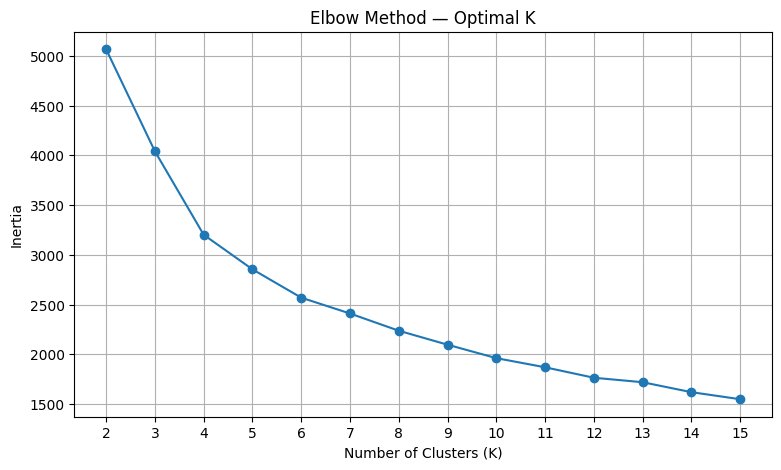

In [ ]:
#Plot and label the Elbow Graph
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

From the Elbow Graph above,
between K = 2 to K = 4, the inertia drops very sharply, which indicates better clustering.
After K = 4 or 5, the decrease becomes much slower, and so adding more clusters gives only small improvement.

Let's evaluate how good the clustering is for different numbers of clusters (between K = 2 and K = 15) using the Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 16):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}  Silhouette: {score:.4f}")

## Let's train the K-Means Model

In [ ]:
# Our Elbow Graph suggests that the best number of clusters is about 4 as that is where the elbow begins

OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_new['cluster'] = kmeans.fit_predict(X_scaled)

print(df_new['cluster'].value_counts().sort_index())

cluster
0    10900
1     3524
2     3517
3     4028
Name: count, dtype: int64


In [ ]:
#Create a profile for each of the 4 clusters to understand it better
cluster_profile = df_new.groupby('cluster').agg(
    count=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_bedrooms=('bedrooms', 'mean'),
    avg_bathrooms=('bathrooms', 'mean'),
    avg_parking=('parking_space', 'mean'),
    top_state=('state', lambda x: x.mode()[0]),
    top_town=('town', lambda x: x.mode()[0]),
    top_title=('title', lambda x: x.mode()[0]),
).reset_index()

print(cluster_profile.to_string())

   cluster  count     avg_price  median_price  avg_bedrooms  avg_bathrooms  avg_parking top_state  top_town          top_title
0        0  10900  4.535407e+08   130000000.0      4.814404       5.018716     4.274128     Lagos     Lekki    Detached Duplex
1        1   3524  2.279246e+08    80000000.0      4.298808       4.631952     3.997730     Abuja  Gwarinpa    Detached Duplex
2        2   3517  1.309886e+08    55000000.0      3.758601       4.046346     3.910151     Lagos      Ajah    Detached Duplex
3        3   4028  2.416799e+08    68000000.0      3.881331       4.175273     3.509186     Lagos     Lekki  Terraced Duplexes


From the above cluster profile, we see that:
- Cluster 1 has 10,900 entries; mean price of: 453.5M
- Cluster 2 has 3,524 entries; mean price: 227.9M
- Cluster 3 has 3,517 entries; mean price: 130.9M
- Cluster 4 has 4,028 entries; mean price: 241.6M

## Let's build the recommendation logic

We will:
- Encode the user's preferences into the same feature space
- Find which cluster they fall closest to
- Return the top-k actual properties from that cluster

In [ ]:
#We'll create a numerical profile of the user's preferences that:
#Takes inputs like bedrooms, bathrooms, parking, budget, location, and property type.
#Converts text values (state, town, title) into numbers using label encoders.
#Applies log transformation to the budget.
#Returns the information as a numeric vector that the ML model can understand.
#recommend_by_cluster function: This is the core recommendation logic.
#It takes user preferences, predicts the most suitable cluster using the loaded K-Means model,
#filters properties within that cluster based on budget, and provides a fallback if no exact budget match is found.
#It then ranks and formats the top recommendations.

def get_user_vector(bedrooms, bathrooms, toilets, parking_space,
                    budget, state, town, title):
    log_budget = np.log1p(budget)
    state_enc  = le_state.transform([state])[0] if state in le_state.classes_ else 0
    town_enc   = le_town.transform([town])[0]   if town  in le_town.classes_  else 0
    title_enc  = le_title.transform([title])[0] if title in le_title.classes_ else 0

    return np.array([[bedrooms, bathrooms, toilets, parking_space,
                      log_budget, state_enc, town_enc, title_enc]])

def recommend_by_cluster(bedrooms, bathrooms, toilets, parking_space,
                          budget_min, budget_max, state=None,
                          town=None, title=None, top_k=5):

    budget_mid = (budget_min + budget_max) / 2

    # Default to most common values if not specified
    state  = state  or df_new['state'].mode()[0]
    town   = town   or df_new['town'].mode()[0]
    title  = title  or df_new['title'].mode()[0]

    # Build and scale user vector
    user_vec = get_user_vector(bedrooms, bathrooms, toilets, parking_space,
                               budget_mid, state, town, title)
    user_scaled = scaler.transform(user_vec)

    # Find the closest cluster
    user_cluster = kmeans.predict(user_scaled)[0]
    print(f"Matched to Cluster {user_cluster}")

    # Filter properties from that cluster within budget
    candidates = df_new[
        (df_new['cluster'] == user_cluster) &
        (df_new['price'] >= budget_min) &
        (df_new['price'] <= budget_max)
    ].copy()

    # Fallback: if no exact match in budget, relax to full cluster
    if candidates.empty:
        print("No exact budget match — showing closest cluster properties.")
        candidates = df_new[df_new['cluster'] == user_cluster].copy()

    # Rank by closeness of price to budget midpoint
    candidates['price_diff'] = abs(candidates['price'] - budget_mid)
    top = candidates.sort_values('price_diff').head(top_k)

    display_cols = ['title', 'town', 'state', 'bedrooms',
                    'bathrooms', 'parking_space', 'price']
    result = top[display_cols].copy()
    result['price'] = result['price'].apply(lambda x: f"₦{x:,.0f}")
    return result

# Example call
#Let's test our recommendation model
#recommend_by_cluster(
  #  bedrooms=3, bathrooms=3, toilets=3, parking_space=2,
  #  budget_min=30_000_000, budget_max=80_000_000,
   # state='Lagos', town='Lekki', title='Flat', top_k=5
#)

# Let's evaluate our model

In [ ]:
#We use Davies-Bouldin Index to evaluate the clustering quality
from sklearn.metrics import silhouette_score, davies_bouldin_score

labels = df_new['cluster'].values
silSco   = silhouette_score(X_scaled, labels)
dbInd    = davies_bouldin_score(X_scaled, labels)

print(f"Silhouette Score:      {silSco:.4f}  (higher is better, max=1.0)")
print(f"Davies-Bouldin Index:  {dbInd:.4f}  (lower is better, min=0.0)")

Silhouette Score:      0.3813  (higher is better, max=1.0)
Davies-Bouldin Index:  0.9980  (lower is better, min=0.0)


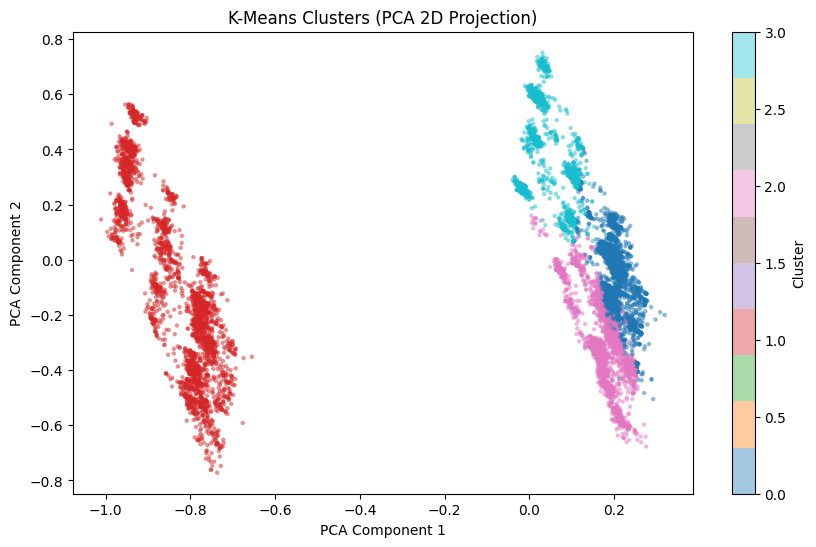

In [ ]:
#Let's visualise the clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=df_new['cluster'], cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

- The plot above reveals that we have two distinct clusters: 1 on the left side (Red), and 3 on the right side
- The right-side clusters (3) have some overlap, meaning those property segments share similar characteristics.

In [ ]:
#Save the trained model and objects
import joblib

joblib.dump(kmeans,  'kmeans_model.pkl')
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(le_state, 'le_state.pkl')
joblib.dump(le_town,  'le_town.pkl')
joblib.dump(le_title, 'le_title.pkl')
df_new.to_csv('nigeria_houses_clustered.csv', index=False)

print("All model artifacts have been saved.")

All model artifacts have been saved.


### Deploy to Streamlit

In [ ]:
!pip install -q streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scipy.spatial.distance import cdist # New import for calculating distances

# Load the trained models and data
kmeans   = joblib.load('kmeans_model.pkl')
scaler   = joblib.load('scaler.pkl')
le_state = joblib.load('le_state.pkl')
le_town  = joblib.load('le_town.pkl')
le_title = joblib.load('le_title.pkl')
df_clustered = pd.read_csv('nigeria_houses_clustered.csv') # Load the clustered data

#Load the filtered dataset
df_original_filtered = pd.read_csv("/content/drive/MyDrive/CapstoneProjectGroup7/filtered_properties.csv")

# Define feature_cols, must match what was used for training the scaler and kmeans
feature_cols_for_scaling = ['bedrooms', 'bathrooms', 'toilets', 'parking_space',
                            'log_price', 'state_enc', 'town_enc', 'title_enc']

# Helper function to create user vector (copied from original notebook cell U4-_ttSVGId2)
def get_user_vector(bedrooms, bathrooms, toilets, parking_space,
                    budget, state, town, title):
    log_budget = np.log1p(budget)
    state_enc  = le_state.transform([state])[0] if state in le_state.classes_ else 0
    town_enc   = le_town.transform([town])[0]   if town  in le_town.classes_  else 0
    title_enc  = le_title.transform([title])[0] if title in le_title.classes_ else 0

    return np.array([[bedrooms, bathrooms, toilets, parking_space,
                      log_budget, state_enc, town_enc, title_enc]])

# Recommendation logic function (copied from original notebook cell U4-_ttSVGId2)
def recommend_by_cluster(bedrooms, bathrooms, toilets, parking_space,
                          budget_min, budget_max, state=None,
                          town=None, title=None, top_k=5):

    budget_mid = (budget_min + budget_max) / 2

    # Default to most common values if not specified (use df_clustered for mode calculation)
    state  = state  or df_clustered['state'].mode()[0]
    town   = town   or df_clustered['town'].mode()[0]
    title  = title  or df_clustered['title'].mode()[0]

    # Build and scale user vector
    user_vec = get_user_vector(bedrooms, bathrooms, toilets, parking_space,
                               budget_mid, state, town, title)
    user_scaled = scaler.transform(user_vec)

    # Find the closest cluster
    user_cluster = kmeans.predict(user_scaled)[0]
    st.write(f"Matched to Cluster {user_cluster}") # Use st.write for Streamlit output

    # Filter properties from that cluster within budget
    candidates = df_clustered[
        (df_clustered['cluster'] == user_cluster) &
        (df_clustered['price'] >= budget_min) &
        (df_clustered['price'] <= budget_max)
    ].copy()

    # Fallback: if no exact match in budget, relax to full cluster
    if candidates.empty:
        st.warning("No exact budget match — showing closest cluster properties.") # Use st.warning for Streamlit output
        candidates = df_clustered[df_clustered['cluster'] == user_cluster].copy()

    # Get the scaled feature vectors for the candidate properties for similarity calculation
    candidate_features_for_dist = df_clustered.loc[candidates.index, feature_cols_for_scaling]
    candidates_scaled_features = scaler.transform(candidate_features_for_dist)

    # Calculate Euclidean distance between user_scaled and each candidate's scaled features
    distances = cdist(user_scaled, candidates_scaled_features, 'euclidean').flatten()
    candidates['feature_distance'] = distances

    # Calculate price difference
    candidates['price_diff'] = abs(candidates['price'] - budget_mid)

    # Rank by feature distance (lower is better), then by price_diff (lower is better)
    # This prioritizes overall feature similarity, then refines by budget closeness
    top = candidates.sort_values(['feature_distance', 'price_diff']).head(top_k)

    display_cols = ['title', 'town', 'state', 'bedrooms',
                    'bathrooms', 'parking_space', 'price']
    result = top[display_cols].copy()
    result['price'] = result['price'].apply(lambda x: f"₦{x:,.0f}")
    return result

# Streamlit app layout
st.title("Nigeria Smart Property Finder")

with st.sidebar:
    st.header("Your Preferences")
    bedrooms  = st.slider("Bedrooms",  1, 10, 3)
    bathrooms = st.slider("Bathrooms", 1, 10, 2)
    toilets   = st.slider("Toilets",   1, 10, 2)
    parking   = st.slider("Parking Spaces", 0, 10, 1)
    budget_min = st.number_input("Minimum Budget (₦)", value=20_000_000, step=5_000_000)
    budget_max = st.number_input("Maximum Budget (₦)", value=80_000_000, step=5_000_000)

    # Use df_original_filtered for selectbox options to ensure consistent and correct state/town unique values
    state  = st.selectbox("State",  sorted(df_original_filtered['state'].unique()))
    town   = st.selectbox("Town",   sorted(df_original_filtered[df_original_filtered['state']==state]['town'].unique()))
    title  = st.selectbox("Property Type", sorted(df_original_filtered['title'].unique()))
    top_k  = st.slider("Results to show", 3, 20, 5)

if st.button("Find Properties"):
    results = recommend_by_cluster(
        bedrooms=bedrooms, bathrooms=bathrooms, toilets=toilets, parking_space=parking,
        budget_min=budget_min, budget_max=budget_max,
        state=state, town=town, title=title, top_k=top_k
    )
    if not results.empty:
        st.dataframe(results)
    else:
        st.info("No properties found matching your criteria.")

st.markdown("---")
st.caption("Project by Real Estate Group | TechCrush Cohort 5 AI")

Overwriting app.py


### Making Streamlit Publicly Accessible with ngrok

To access your Streamlit app from a public URL, we'll use `ngrok`.

1.  **Sign up for ngrok**: Go to [ngrok.com](https://ngrok.com/signup) and sign up for a free account.
2.  **Get your Auth Token**: After signing up, go to your [dashboard](https://dashboard.ngrok.com/get-started/your-authtoken) to find your `Authtoken`.
3.  **Add to Colab Secrets**: In Colab, click the "🔑" icon on the left sidebar, add a new secret, name it `NGROK_AUTH_TOKEN`, and paste your ngrok authtoken as the value. Make sure to enable "Notebook access" for this secret.


In [ ]:
import os
from pyngrok import conf
from google.colab import userdata

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Authenticate ngrok
conf.get_default().auth_token = NGROK_AUTH_TOKEN

Now, run your Streamlit app. After executing the cell below, click on the `public_url` printed above to access your app.

In [ ]:
import subprocess
import time
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Run Streamlit in the background
# We use subprocess.Popen instead of !streamlit to ensure it runs without blocking
# and allows the ngrok tunnel to remain active.
process = subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'])

# Give Streamlit some time to start up
time.sleep(5) # You might need to adjust this delay

# Open a ngrok tunnel to the Streamlit port (8501)
public_url = ngrok.connect(8501)
print(f"Streamlit app will be available at: {public_url}")

Streamlit app will be available at: NgrokTunnel: "https://vaporizable-unodored-kathline.ngrok-free.dev" -> "http://localhost:8501"


To stop the Streamlit app and the ngrok tunnel, you can run the following cell:

In [ ]:
# Stop the Streamlit process
if 'process' in locals() and process.poll() is None:
    process.terminate()
    process.wait()
    print("Streamlit app stopped.")

# Disconnect ngrok tunnels
from pyngrok import ngrok # Import ngrok here to ensure it's defined
ngrok.kill()
print("ngrok tunnels disconnected.")

ngrok tunnels disconnected.


In [ ]:
!curl ipv4.icanhazip.com


35.229.215.85


In [2]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')